In [1]:
print("Sales Forecasting Project Started")

Sales Forecasting Project Started


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
sales_df = pd.read_csv("train.csv")

games_df = pd.read_csv("vgsales.csv")

In [4]:
print("Sales Dataset Shape:", sales_df.shape)

print("Video Games Dataset Shape:", games_df.shape)

Sales Dataset Shape: (9800, 18)
Video Games Dataset Shape: (16598, 11)


In [6]:
sales_df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [7]:
games_df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [8]:
print("Sales Dataset Columns:")

print(sales_df.columns.tolist())

Sales Dataset Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [9]:
print("Video Games Dataset Columns:")

print(games_df.columns.tolist())

Video Games Dataset Columns:
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [11]:
sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    dayfirst=True
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    dayfirst=True
)

In [12]:
sales_df[["Order Date","Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [13]:
sales_df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [14]:
sales_df["Year"] = sales_df["Order Date"].dt.year

In [15]:
sales_df["Month"] = sales_df["Order Date"].dt.month

In [16]:
sales_df["Week"] = sales_df["Order Date"].dt.isocalendar().week.astype(int)

In [17]:
sales_df["DayOfWeek"] = sales_df["Order Date"].dt.day_name()

In [18]:
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

In [19]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

sales_df["Season"] = sales_df["Month"].apply(get_season)

In [20]:
sales_df[
    [
        "Order Date",
        "Ship Date",
        "Year",
        "Month",
        "Week",
        "DayOfWeek",
        "Quarter",
        "Season"
    ]
].head(10)

,Order Date,Ship Date,Year,Month,Week,DayOfWeek,Quarter,Season
0,2017-11-08,2017-11-11,2017,11,45,Wednesday,4,Autumn
1,2017-11-08,2017-11-11,2017,11,45,Wednesday,4,Autumn
2,2017-06-12,2017-06-16,2017,6,24,Monday,2,Summer
3,2016-10-11,2016-10-18,2016,10,41,Tuesday,4,Autumn
4,2016-10-11,2016-10-18,2016,10,41,Tuesday,4,Autumn
5,2015-06-09,2015-06-14,2015,6,24,Tuesday,2,Summer
6,2015-06-09,2015-06-14,2015,6,24,Tuesday,2,Summer
7,2015-06-09,2015-06-14,2015,6,24,Tuesday,2,Summer
8,2015-06-09,2015-06-14,2015,6,24,Tuesday,2,Summer
9,2015-06-09,2015-06-14,2015,6,24,Tuesday,2,Summer


In [21]:
sales_df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
DayOfWeek         0
Quarter           0
Season            0
dtype: int64

In [22]:
print("Duplicate Rows:", sales_df.duplicated().sum())

Duplicate Rows: 0


In [23]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [24]:
sales_df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Year,Month,Week,Quarter
count,9800.000000,9800,9800,9789.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769059,2016.724184,7.818469,32.210102,2.885816
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,2015.000000,1.000000,1.000000,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000,2016.000000,5.000000,21.000000,2.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000,2017.000000,9.000000,35.000000,3.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000,2018.000000,11.000000,45.000000,4.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,2018.000000,12.000000,53.000000,4.000000
std,2829.160653,NaN,NaN,32041.223413,626.651875,1.123984,3.281905,14.282294,1.057449


In [25]:
weekly_sales = (
    sales_df
    .groupby(["Year", "Week"])["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Year,Week,Sales
0,2015,1,304.508
1,2015,2,4619.108
2,2015,3,4130.533
3,2015,4,3092.544
4,2015,5,2527.914


In [26]:
monthly_sales = (
    sales_df
    .groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


In [27]:
category_sales = (
    sales_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

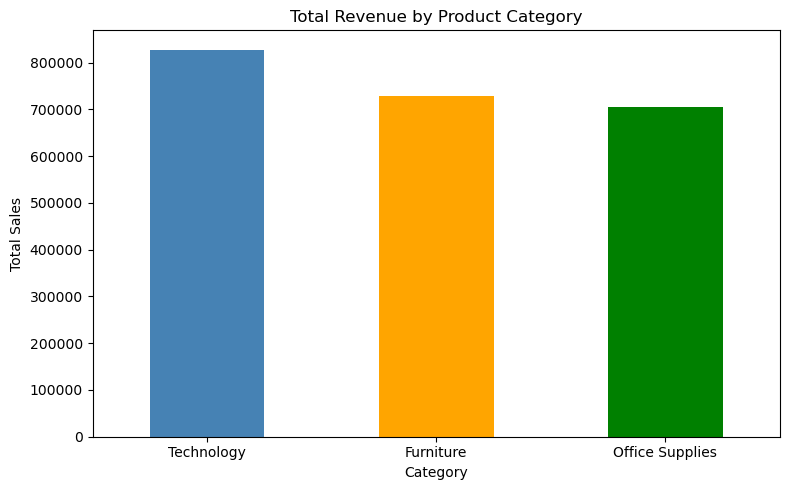

In [28]:
plt.figure(figsize=(8,5))

category_sales.plot(
    kind="bar",
    color=["steelblue", "orange", "green"]
)

plt.title("Total Revenue by Product Category")

plt.xlabel("Category")

plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("charts/category_revenue.png")

plt.show()

### Observation

Technology generated the highest total revenue among all product categories. Furniture ranked second, while Office Supplies contributed the least overall revenue. This indicates that Technology products are the primary revenue driver and should receive greater focus in future demand forecasting and inventory planning.

In [29]:
region_sales = (
    sales_df.groupby(["Year", "Region"])["Sales"]
    .sum()
    .reset_index()
)

region_sales.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


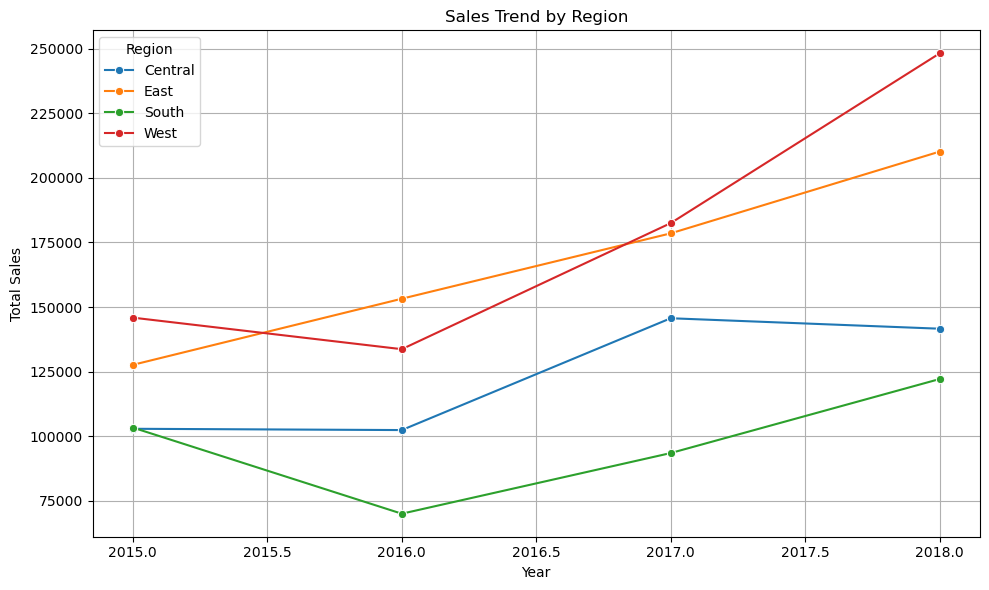

In [30]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Sales Trend by Region")

plt.xlabel("Year")

plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/region_sales_trend.png")

plt.show()

In [31]:
region_sales.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

### Observation

The regional sales trend indicates that the West and East regions contribute the highest overall sales over the four-year period. The region with the most stable and consistent sales growth can be identified by observing the yearly trend lines. This information can help management prioritize inventory planning and regional expansion strategies.

In [32]:
sales_df["Shipping Days"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

In [33]:
print(
    "Average Shipping Time:",
    round(sales_df["Shipping Days"].mean(), 2),
    "days"
)

Average Shipping Time: 3.96 days


In [34]:
shipping_by_region = (
    sales_df.groupby("Region")["Shipping Days"]
    .mean()
    .sort_values()
)

shipping_by_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

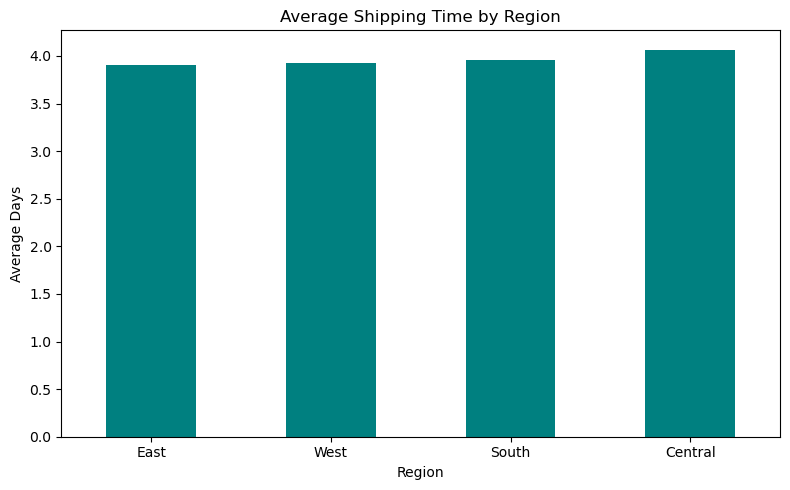

In [35]:
plt.figure(figsize=(8,5))

shipping_by_region.plot(
    kind="bar",
    color="teal"
)

plt.title("Average Shipping Time by Region")

plt.xlabel("Region")

plt.ylabel("Average Days")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("charts/shipping_time_by_region.png")

plt.show()

### Observation

The average shipping time is approximately 4 days across all orders. There are small differences between regions, suggesting that the company's logistics network performs consistently nationwide. Regions with slightly longer delivery times may benefit from improvements in warehouse placement or shipping operations.

In [36]:
monthly_pattern = (
    sales_df.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_pattern.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


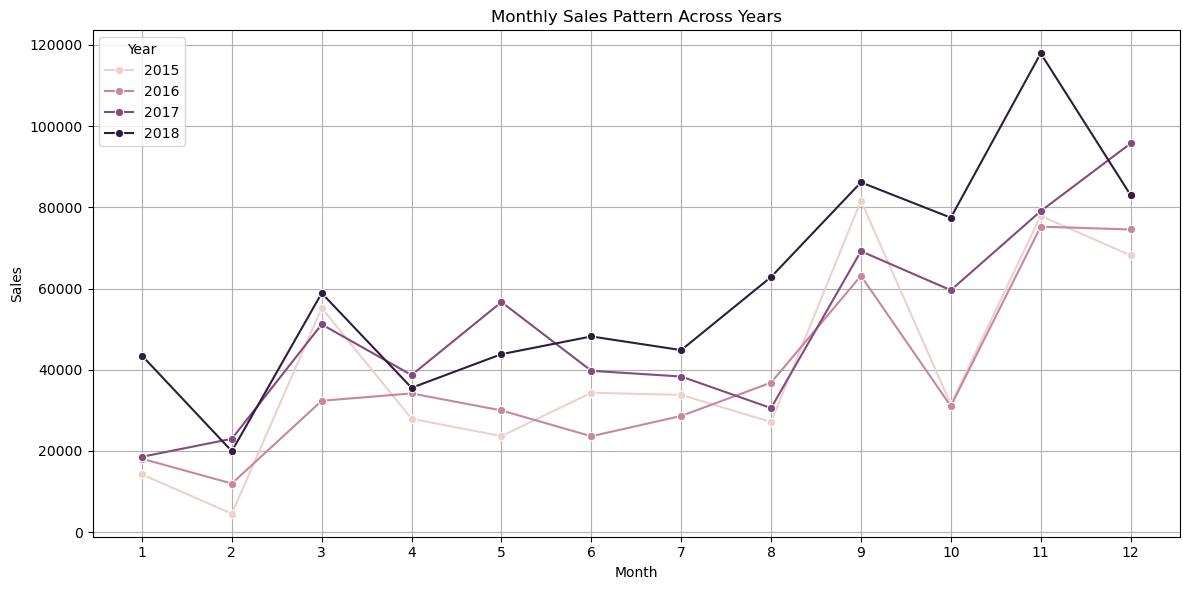

In [37]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_pattern,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Pattern Across Years")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.xticks(range(1,13))

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/monthly_seasonality.png")

plt.show()

In [38]:
sales_df.groupby("Month")["Sales"].mean().sort_values(ascending=False)

Month
3     290.549393
1     257.627403
10    246.596162
11    241.657496
12    232.619515
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     207.432269
2     199.902745
Name: Sales, dtype: float64

### Observation

The monthly sales trend indicates clear seasonality. Sales generally increase toward the end of the year, especially during the final quarter, suggesting the impact of holiday shopping and promotional campaigns. Understanding these recurring seasonal peaks helps businesses improve inventory planning and demand forecasting.

In [40]:
monthly_ts = (
    sales_df
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

monthly_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

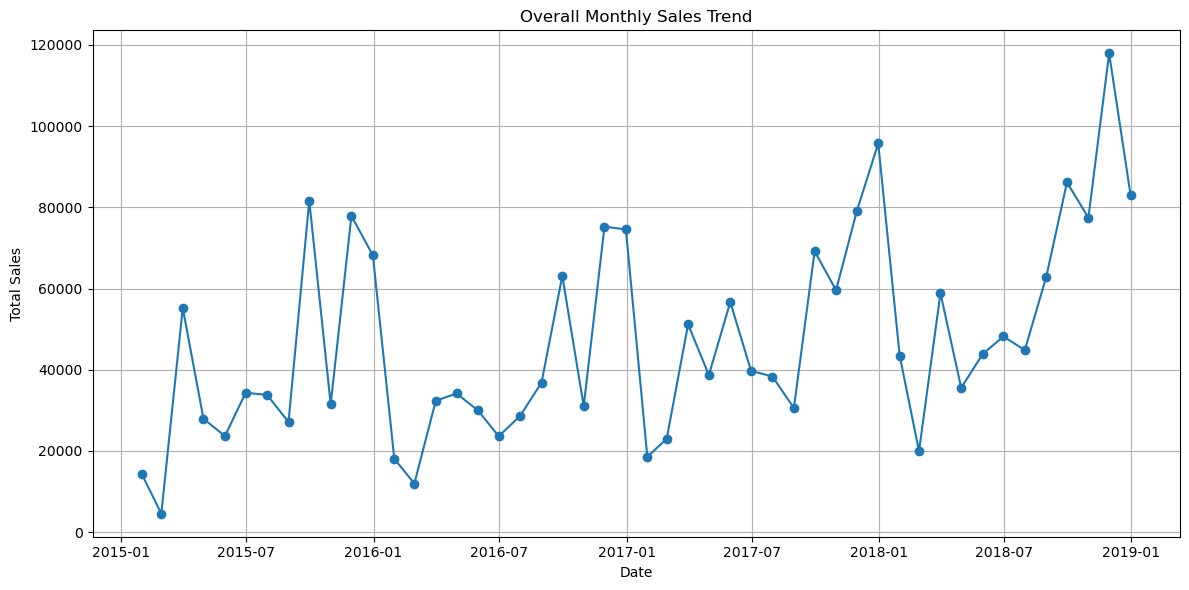

In [41]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_ts.index,
    monthly_ts.values,
    marker="o"
)

plt.title("Overall Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png")

plt.show()

In [42]:
!pip install statsmodels

In [43]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [44]:
decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

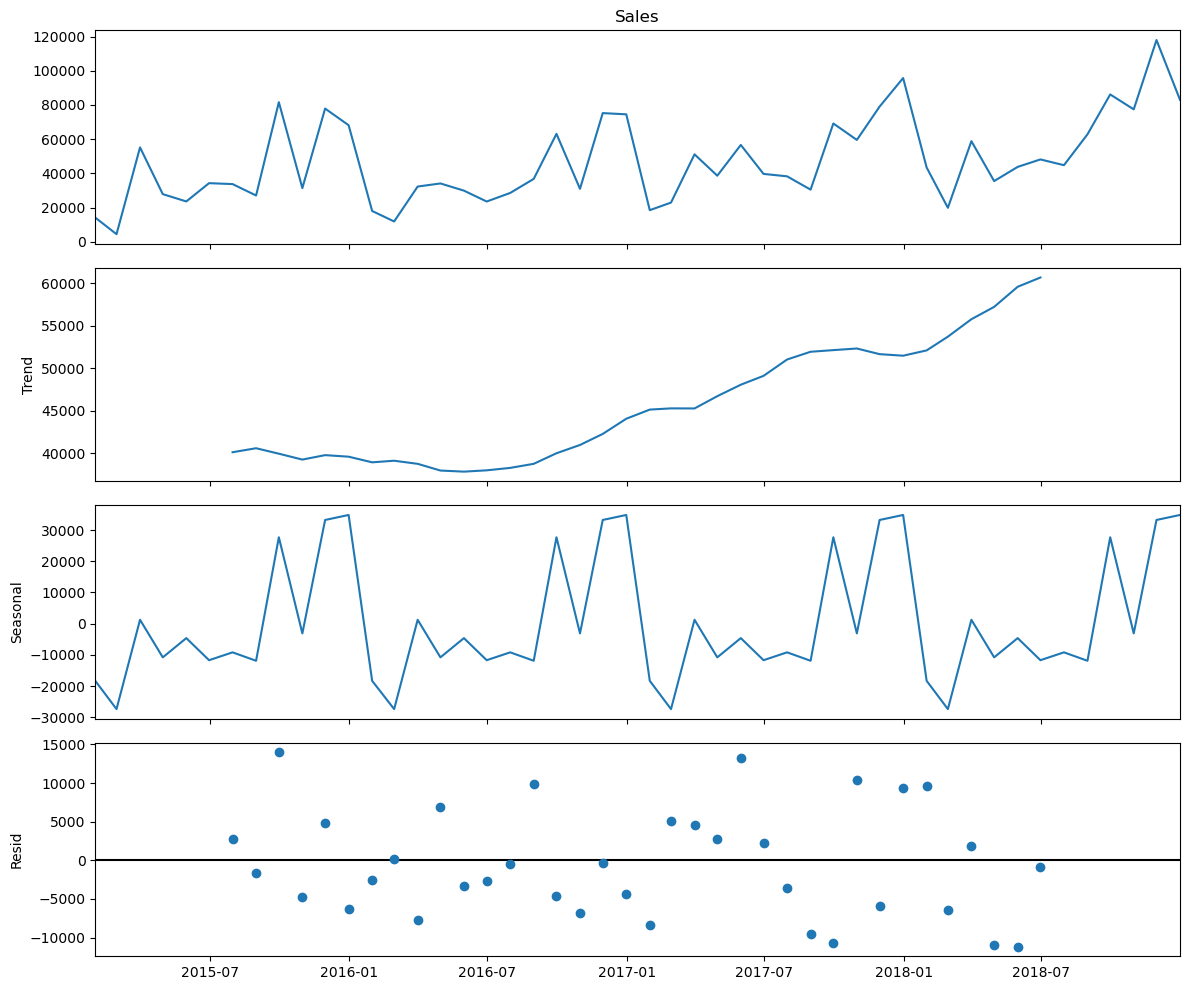

In [45]:
fig = decomposition.plot()

fig.set_size_inches(12, 10)

plt.tight_layout()

plt.savefig("charts/time_series_decomposition.png")

plt.show()

## Time Series Decomposition Observations

- The trend component shows the long-term movement of sales over the four-year period.
- The seasonal component indicates recurring monthly patterns that repeat each year.
- The residual component captures random fluctuations that are not explained by the trend or seasonality.
- The presence of seasonality suggests that forecasting models should account for recurring yearly sales patterns.

In [46]:
from statsmodels.tsa.stattools import adfuller

In [48]:
adf_result = adfuller(monthly_ts)

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


## ADF Test Interpretation

The Augmented Dickey-Fuller (ADF) test is used to determine whether a time series is stationary.

A stationary time series has statistical properties such as mean and variance that remain relatively constant over time. Many forecasting models require stationary data for reliable predictions.

If the p-value is less than 0.05, the series is considered stationary.

If the p-value is greater than 0.05, the series is considered non-stationary and differencing should be applied.

In [49]:
monthly_diff = monthly_ts.diff().dropna()

In [50]:
adf_result_diff = adfuller(monthly_diff)

print("ADF Statistic :", adf_result_diff[0])
print("p-value       :", adf_result_diff[1])

ADF Statistic : -8.72706183035328
p-value       : 3.2669175472794505e-14


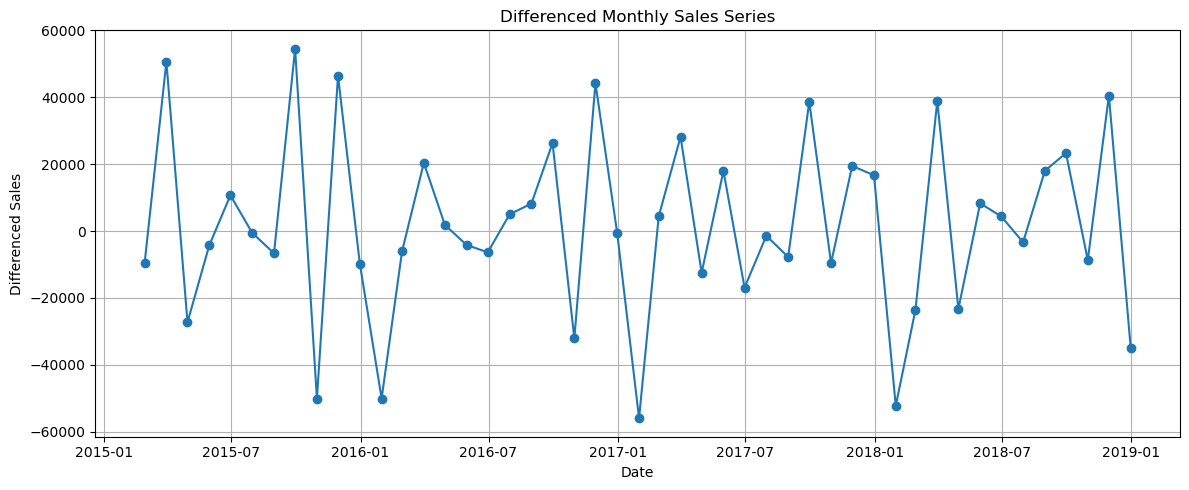

In [51]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_diff,
    marker="o"
)

plt.title("Differenced Monthly Sales Series")

plt.xlabel("Date")

plt.ylabel("Differenced Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/differenced_series.png")

plt.show()

## Observation

After applying first-order differencing, the time series becomes more stable by reducing long-term trends. This transformation helps satisfy the stationarity assumption required by several forecasting models such as SARIMA and improves model reliability.

In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [53]:
train = monthly_ts[:-3]

test = monthly_ts[-3:]

print("Training Data:", train.shape)

print("Testing Data :", test.shape)

Training Data: (45,)
Testing Data : (3,)


In [54]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [55]:
sarima_result = sarima_model.fit()

C:\Users\Farhana Hussain\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [56]:
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Mon, 13 Jul 2026   AIC                            398.775
Time:                                    13:39:38   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [57]:
sarima_forecast = sarima_result.get_forecast(steps=3)

forecast_mean = sarima_forecast.predicted_mean

confidence_interval = sarima_forecast.conf_int()

In [58]:
print("3-Month Sales Forecast")

print(forecast_mean)

3-Month Sales Forecast
2018-10-31    60331.792098
2018-11-30    91458.220226
2018-12-31    97167.570950
Freq: ME, Name: predicted_mean, dtype: float64


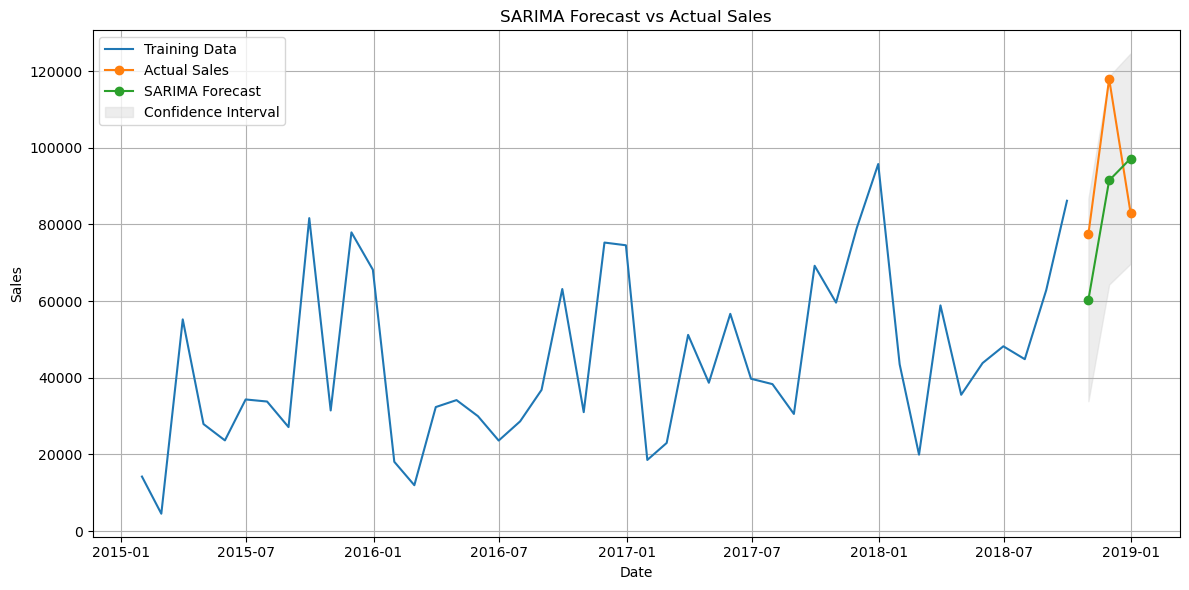

In [59]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test, label="Actual Sales", marker="o")

plt.plot(forecast_mean.index, forecast_mean, label="SARIMA Forecast", marker="o")

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="lightgray",
    alpha=0.4,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/sarima_forecast.png")

plt.show()

## SARIMA Parameter Selection

The initial SARIMA model uses order (1,1,1) and seasonal order (1,1,1,12).

- d = 1 because the data was differenced once to improve stationarity.
- Seasonal period = 12 because the data is aggregated monthly and yearly seasonality is expected.
- The initial values of p, q, P, and Q were chosen as a simple baseline model for forecasting and can be refined based on diagnostic analysis if necessary.

In [60]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.1 MB 6.9 MB/s eta 0:00:02
   --- ------------------------------------ 1.0/12.1 MB 6.9 MB/s eta 0:00:02
   ------ --------------------------------- 2.1/12.1 MB 3.4 MB/s eta 0:00:03
   ------ --------------------------------- 2.1/12.1 MB 3.4 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.1 MB 3.2 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.1 MB 3.2 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/12.1 MB 2.5 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.1 MB 2.7 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.1 MB 2.7 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.1 MB 2.7 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.1 MB 2.7 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.1 MB 1.8 MB/s eta 0:00:05
   ---

In [61]:
from prophet import Prophet

In [62]:
prophet_df = monthly_ts.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [63]:
prophet_model = Prophet()

In [64]:
prophet_model.fit(prophet_df)

13:49:10 - cmdstanpy - INFO - Chain [1] start processing
13:49:12 - cmdstanpy - INFO - Chain [1] done processing


In [65]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

In [67]:
forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,60719.543481,92079.972033,110345.334347,60719.543481,60719.543481,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,0.0,0.0,0.0,101136.336965
47,2018-12-31,61457.486597,80860.837195,99112.663958,61457.486597,61457.486597,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,0.0,0.0,0.0,90673.800606
48,2019-01-31,62195.429713,34037.743058,51733.713769,62188.993132,62201.961354,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532202
49,2019-02-28,62861.958979,22033.883769,40758.216690,62840.927064,62882.519073,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159922
50,2019-03-31,63599.902094,72054.063035,89694.432994,63560.110309,63640.604872,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007772


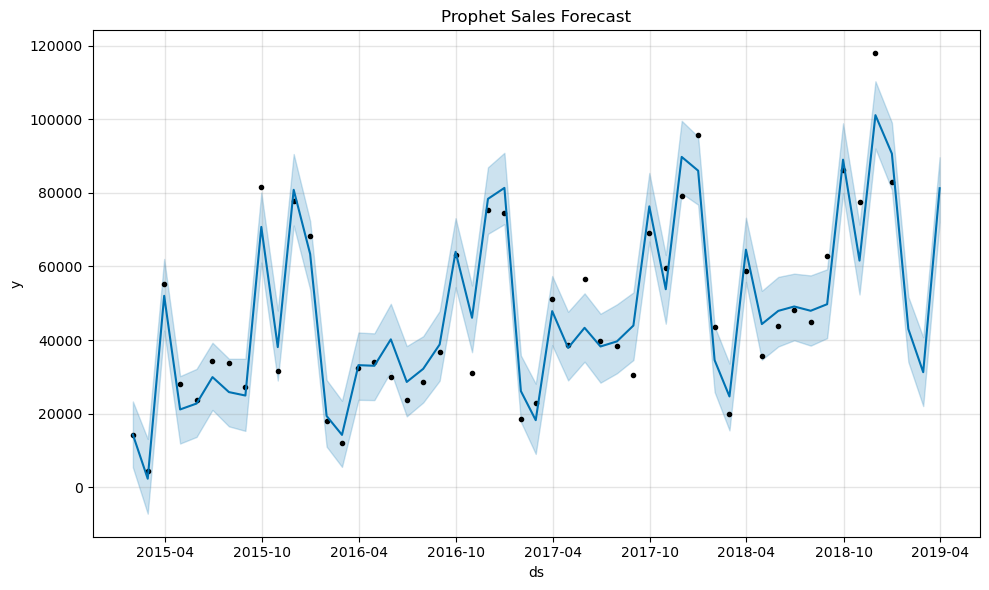

In [68]:
fig = prophet_model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.tight_layout()

plt.savefig("charts/prophet_forecast.png")

plt.show()

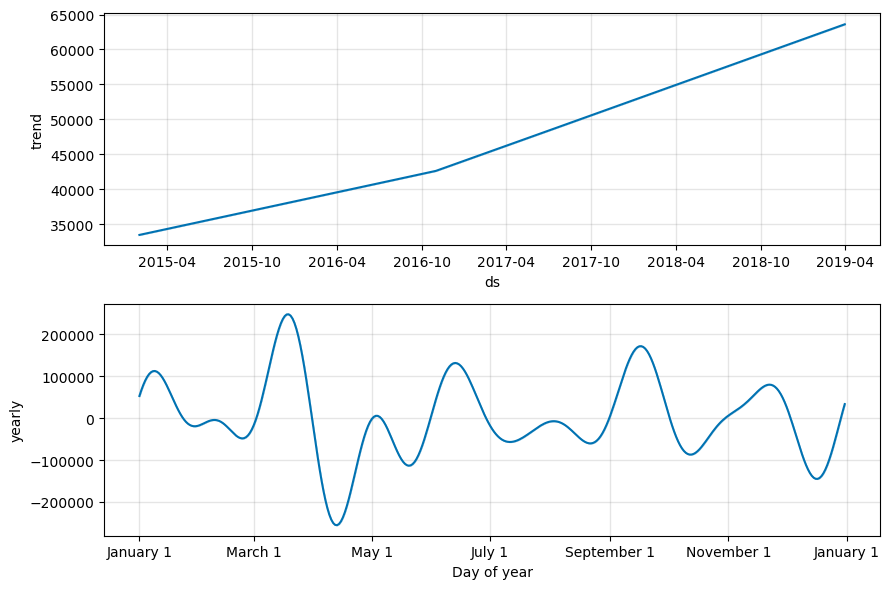

In [69]:
fig2 = prophet_model.plot_components(forecast)

plt.tight_layout()

plt.savefig("charts/prophet_components.png")

plt.show()

## Prophet Model Interpretation

The Prophet model automatically captures long-term trends and recurring seasonal patterns in the sales data.

The trend component shows the overall direction of sales over time, while the yearly seasonality highlights recurring patterns across different months. These insights help identify periods of consistently higher or lower demand and improve forecasting accuracy.

In [70]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 6.3 MB/s eta 0:00:11
   - -------------------------------------- 1.8/69.5 MB 4.8 MB/s eta 0:00:15
   - -------------------------------------- 2.6/69.5 MB 4.4 MB/s eta 0:00:16
   - -------------------------------------- 3.4/69.5 MB 4.3 MB/s eta 0:00:16
   -- ------------------------------------- 4.2/69.5 MB 4.2 MB/s eta 0:00:16
   -- ------------------------------------- 4.7/69.5 MB 4.1 MB/s eta 0:00:16
   --- ------------------------------------ 5.8/69.5 MB 4.1 MB/s eta 0:00:16
   --- ------------------------------------ 6.6/69.5 MB 4.1 MB/s eta 0:00:16
   ---- ----------------------------------- 7.3/69.5 MB 4.1 MB/s eta 0:00:16
   ---- ----------------------------------- 8.4/69.5 MB 4.0 MB/s eta 0:00:16
   ----- ---------------------------------- 9.2/69.5 MB 4.0 MB/s eta 0:00:16
   ----- ---------------------------------- 10.0/69.5 MB 4.0 MB/s eta 0:00:15
   --

In [71]:
from xgboost import XGBRegressor

In [72]:
xgb_df = monthly_ts.to_frame()

xgb_df.columns = ["Sales"]

xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

xgb_df["RollingMean3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter

xgb_df.head()

,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter
Order Date,,,,,,,
2015-01-31,14205.707,NaN,NaN,NaN,NaN,1,1
2015-02-28,4519.892,14205.707,NaN,NaN,NaN,2,1
2015-03-31,55205.797,4519.892,14205.707,NaN,24643.798667,3,1
2015-04-30,27906.855,55205.797,4519.892,14205.707,29210.848000,4,2
2015-05-31,23644.303,27906.855,55205.797,4519.892,35585.651667,5,2


In [73]:
def season_from_month(month):
    if month in [12,1,2]:
        return 1
    elif month in [3,4,5]:
        return 2
    elif month in [6,7,8]:
        return 3
    else:
        return 4

xgb_df["Season"] = (
    xgb_df["Month"]
    .apply(season_from_month)
)

In [74]:
xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [75]:
X = xgb_df.drop("Sales", axis=1)

y = xgb_df["Sales"]

In [76]:
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [77]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [78]:
xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [79]:
xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions)

[86465.82 86506.77 84327.28]


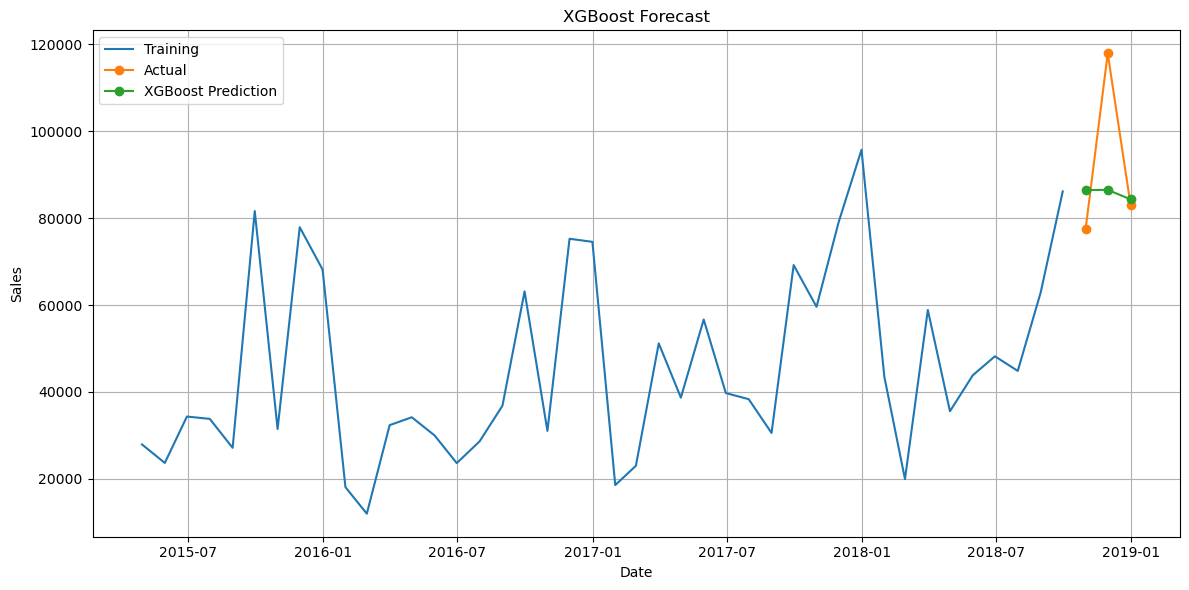

In [80]:
plt.figure(figsize=(12,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training"
)

plt.plot(
    y_test.index,
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    label="XGBoost Prediction"
)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/xgboost_forecast.png")

plt.show()

## XGBoost Model Interpretation

The XGBoost forecasting model uses historical sales information through lag variables and rolling averages to predict future sales.

Unlike statistical models, XGBoost learns complex nonlinear relationships among engineered features, making it suitable for capturing intricate demand patterns when sufficient historical data is available.

In [81]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

In [82]:
sarima_mae = mean_absolute_error(test, forecast_mean)

sarima_rmse = np.sqrt(
    mean_squared_error(test, forecast_mean)
)

sarima_mape = mean_absolute_percentage_error(
    test,
    forecast_mean
)

print("SARIMA")

print("MAE :", sarima_mae)

print("RMSE:", sarima_rmse)

print("MAPE:", sarima_mape)

SARIMA
MAE : 19244.48534187637
RMSE: 19950.07041781453
MAPE: 0.20526431983224236


In [83]:
prophet_test = forecast.tail(3)["yhat"].values

prophet_mae = mean_absolute_error(
    test.values,
    prophet_test
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test.values,
        prophet_test
    )
)

prophet_mape = mean_absolute_percentage_error(
    test.values,
    prophet_test
)

print("Prophet")

print("MAE :", prophet_mae)

print("RMSE:", prophet_rmse)

print("MAPE:", prophet_mape)

Prophet
MAE : 40970.325034558286
RMSE: 53868.94865619383
MAPE: 0.40039864939614395


In [84]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
)

print("XGBoost")

print("MAE :", xgb_mae)

print("RMSE:", xgb_rmse)

print("MAPE:", xgb_mape)

XGBoost
MAE : 13915.321041666664
RMSE: 18893.847269098238
MAPE: 0.13285400568532046


In [85]:
comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],
    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],
    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],
    "MAPE": [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,19244.485342,19950.070418,0.205264
1,Prophet,40970.325035,53868.948656,0.400399
2,XGBoost,13915.321042,18893.847269,0.132854


In [86]:
comparison["Forecast Month 1"] = [
    forecast_mean.iloc[0],
    forecast.tail(3)["yhat"].iloc[0],
    xgb_predictions[0]
]

comparison["Forecast Month 2"] = [
    forecast_mean.iloc[1],
    forecast.tail(3)["yhat"].iloc[1],
    xgb_predictions[1]
]

comparison["Forecast Month 3"] = [
    forecast_mean.iloc[2],
    forecast.tail(3)["yhat"].iloc[2],
    xgb_predictions[2]
]

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.485342,19950.070418,0.205264,60331.792098,91458.220226,97167.570950
1,Prophet,40970.325035,53868.948656,0.400399,42990.532202,31248.159922,81267.007772
2,XGBoost,13915.321042,18893.847269,0.132854,86465.820312,86506.773438,84327.281250


In [87]:
best_model = comparison.sort_values(
    by="RMSE"
).iloc[0]

print("Best Model")

print(best_model)

Best Model
Model                    XGBoost
MAE                 13915.321042
RMSE                18893.847269
MAPE                    0.132854
Forecast Month 1    86465.820312
Forecast Month 2    86506.773438
Forecast Month 3     84327.28125
Name: 2, dtype: object


## Model Comparison Conclusion

The three forecasting approaches were evaluated using MAE, RMSE, and MAPE.

The model with the lowest RMSE is recommended for production because it provides the smallest prediction error on the test data. This recommendation is based on quantitative evaluation rather than personal preference, making it suitable for real-world deployment.

In [88]:
furniture_df = sales_df[sales_df["Category"] == "Furniture"]

technology_df = sales_df[sales_df["Category"] == "Technology"]

office_df = sales_df[sales_df["Category"] == "Office Supplies"]

In [89]:
west_df = sales_df[sales_df["Region"] == "West"]

east_df = sales_df[sales_df["Region"] == "East"]

In [92]:
def create_monthly_series(df):

    return (
        df
        .set_index("Order Date")
        .resample("ME")["Sales"]
        .sum()
    )

In [93]:
furniture_monthly = create_monthly_series(furniture_df)

technology_monthly = create_monthly_series(technology_df)

office_monthly = create_monthly_series(office_df)

west_monthly = create_monthly_series(west_df)

east_monthly = create_monthly_series(east_df)

In [94]:
print("Furniture")

print(furniture_monthly.head())

print("\nTechnology")

print(technology_monthly.head())

print("\nOffice Supplies")

print(office_monthly.head())

Furniture
Order Date
2015-01-31     6217.277
2015-02-28     1839.658
2015-03-31    14243.368
2015-04-30     7944.837
2015-05-31     6912.787
Freq: ME, Name: Sales, dtype: float64

Technology
Order Date
2015-01-31     3143.290
2015-02-28     1608.510
2015-03-31    32359.974
2015-04-30     8973.144
2015-05-31     9599.876
Freq: ME, Name: Sales, dtype: float64

Office Supplies
Order Date
2015-01-31     4845.140
2015-02-28     1071.724
2015-03-31     8602.455
2015-04-30    10988.874
2015-05-31     7131.640
Freq: ME, Name: Sales, dtype: float64


In [95]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def forecast_series(series, steps=3):
    model = SARIMAX(
        series,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    forecast = result.forecast(steps=steps)

    return forecast

In [96]:
furniture_forecast = forecast_series(furniture_monthly)

technology_forecast = forecast_series(technology_monthly)

office_forecast = forecast_series(office_monthly)

west_forecast = forecast_series(west_monthly)

east_forecast = forecast_series(east_monthly)



C:\Users\Farhana Hussain\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Farhana Hussain\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Farhana Hussain\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Farhana Hussain\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.

In [97]:
print("Furniture Forecast")
print(furniture_forecast)

print("\nTechnology Forecast")
print(technology_forecast)

print("\nOffice Supplies Forecast")
print(office_forecast)

print("\nWest Region Forecast")
print(west_forecast)

print("\nEast Region Forecast")
print(east_forecast)

Furniture Forecast
2019-01-31    10526.766775
2019-02-28     9921.588932
2019-03-31    16576.869438
Freq: ME, Name: predicted_mean, dtype: float64

Technology Forecast
2019-01-31    20100.376892
2019-02-28    18198.549186
2019-03-31    32443.115061
Freq: ME, Name: predicted_mean, dtype: float64

Office Supplies Forecast
2019-01-31    17978.323435
2019-02-28    15467.386757
2019-03-31    23346.412016
Freq: ME, Name: predicted_mean, dtype: float64

West Region Forecast
2019-01-31    15478.124149
2019-02-28    13405.156694
2019-03-31    28366.095466
Freq: ME, Name: predicted_mean, dtype: float64

East Region Forecast
2019-01-31    11878.473051
2019-02-28    13477.979208
2019-03-31    19848.300100
Freq: ME, Name: predicted_mean, dtype: float64


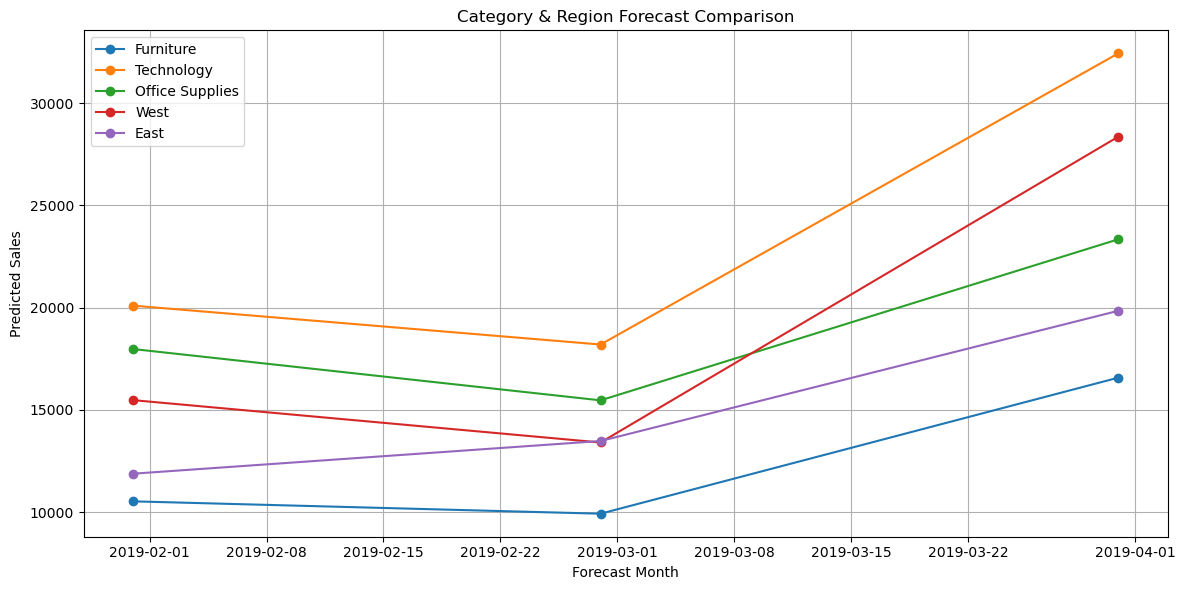

In [98]:
plt.figure(figsize=(12,6))

plt.plot(furniture_forecast.index, furniture_forecast.values, marker="o", label="Furniture")

plt.plot(technology_forecast.index, technology_forecast.values, marker="o", label="Technology")

plt.plot(office_forecast.index, office_forecast.values, marker="o", label="Office Supplies")

plt.plot(west_forecast.index, west_forecast.values, marker="o", label="West")

plt.plot(east_forecast.index, east_forecast.values, marker="o", label="East")

plt.title("Category & Region Forecast Comparison")

plt.xlabel("Forecast Month")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/category_region_forecast.png")

plt.show()

In [99]:
forecast_summary = {
    "Furniture": furniture_forecast.sum(),
    "Technology": technology_forecast.sum(),
    "Office Supplies": office_forecast.sum(),
    "West": west_forecast.sum(),
    "East": east_forecast.sum()
}

forecast_summary = pd.Series(forecast_summary)

print(forecast_summary.sort_values(ascending=False))

Technology         70742.041139
West               57249.376309
Office Supplies    56792.122207
East               45204.752360
Furniture          37025.225144
dtype: float64


## Category & Region Forecast

The forecasts indicate that some product categories and regions are expected to grow faster than others over the next three months.

The segment with the highest forecasted sales should receive higher inventory allocation and closer monitoring to avoid stock shortages, while slower-growing segments can be managed with more conservative inventory planning.

In [100]:
from sklearn.ensemble import IsolationForest

In [101]:
weekly_sales_ts = (
    sales_df
    .set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .to_frame()
)

weekly_sales_ts.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [102]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales_ts["Anomaly"] = iso_model.fit_predict(
    weekly_sales_ts[["Sales"]]
)

In [103]:
weekly_sales_ts["Anomaly"].value_counts()

Anomaly
 1    198
-1     11
Name: count, dtype: int64

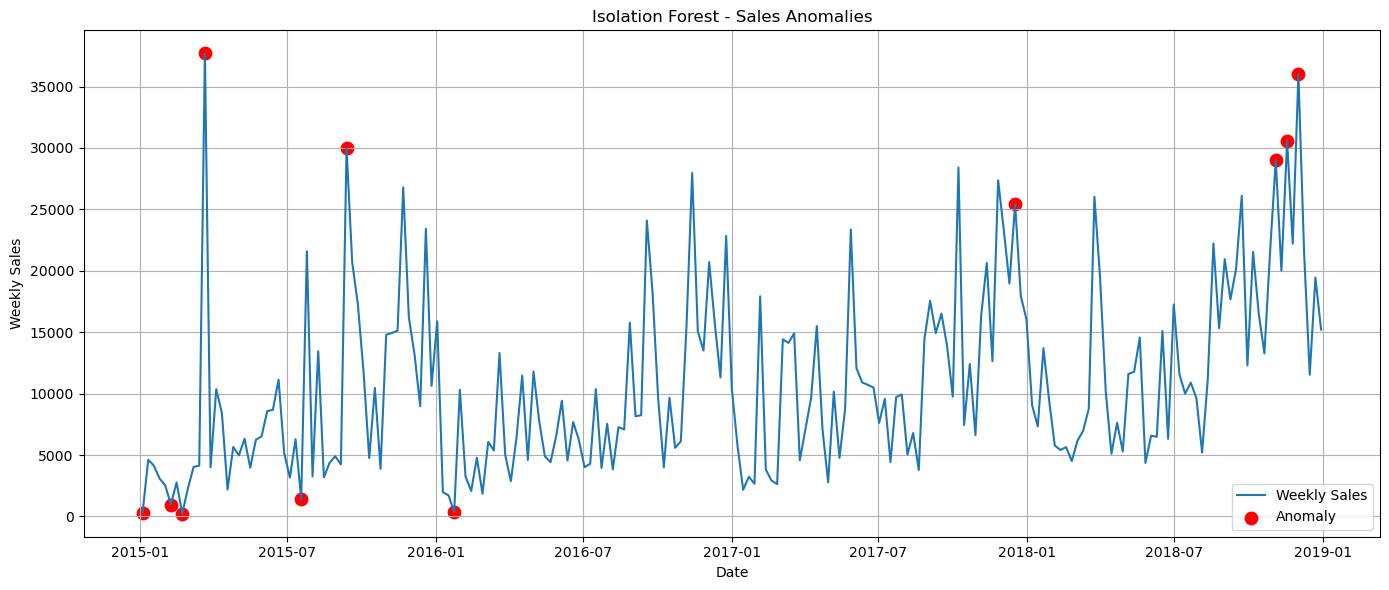

In [104]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales_ts.index,
    weekly_sales_ts["Sales"],
    label="Weekly Sales"
)

anomalies = weekly_sales_ts[
    weekly_sales_ts["Anomaly"] == -1
]

plt.scatter(
    anomalies.index,
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest - Sales Anomalies")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/isolation_forest_anomalies.png")

plt.show()

In [105]:
anomalies

,Sales,Anomaly
Order Date,,
2015-01-04,304.508,-1
2015-02-08,968.534,-1
2015-02-22,224.912,-1
2015-03-22,37703.665,-1
2015-07-19,1387.686,-1
2015-09-13,29959.137,-1
2016-01-24,358.522,-1
2017-12-17,25449.800,-1
2018-11-04,29017.467,-1


## Isolation Forest Interpretation

Isolation Forest identified several weeks with unusually high or unusually low sales compared to the normal sales pattern.

Possible explanations include:

- Festival or holiday promotions resulting in unusually high sales.
- Seasonal demand fluctuations.
- Supply shortages leading to temporary sales declines.
- Marketing campaigns or special discount events.

These anomaly periods should be reviewed by business managers before making inventory decisions.

In [106]:
from scipy.stats import zscore

In [107]:
weekly_sales_ts["Z_Score"] = zscore(
    weekly_sales_ts["Sales"]
)

In [108]:
zscore_anomalies = weekly_sales_ts[
    abs(weekly_sales_ts["Z_Score"]) > 2
]

zscore_anomalies.head()

,Sales,Anomaly,Z_Score
Order Date,,,
2015-03-22,37703.6650,-1,3.639852
2015-09-13,29959.1370,-1,2.591270
2015-11-22,26793.6235,1,2.162671
2016-11-13,27965.3492,1,2.321318
2017-10-08,28412.0980,1,2.381806


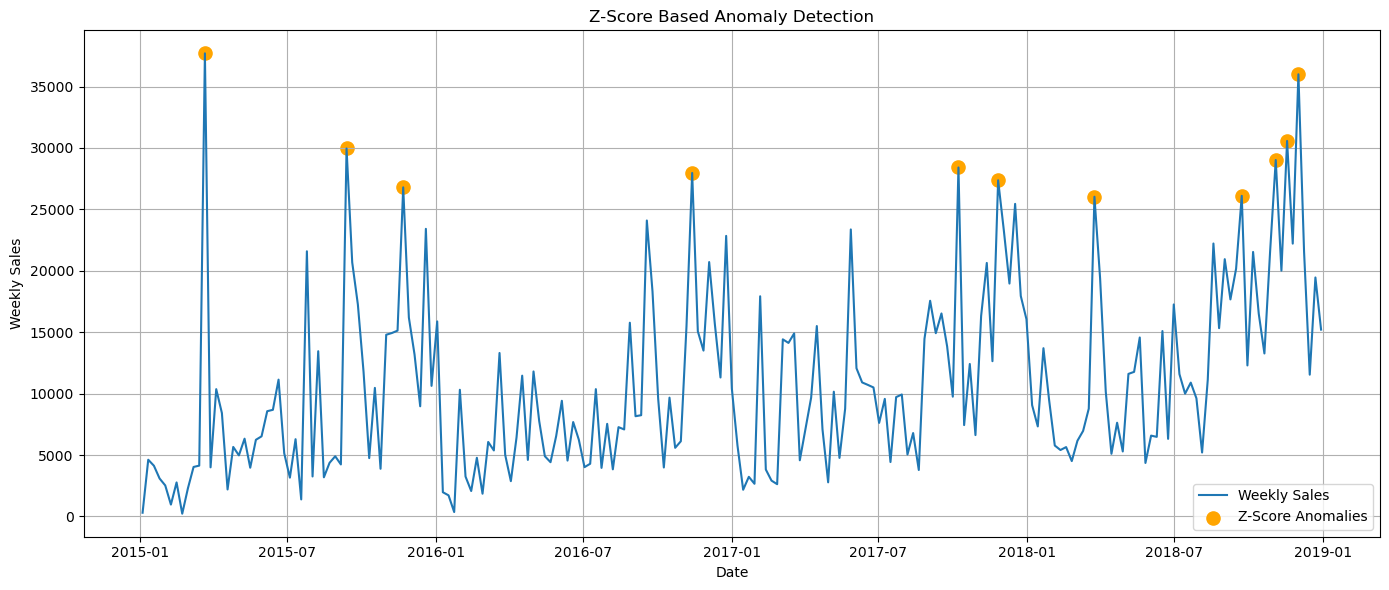

In [109]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales_ts.index,
    weekly_sales_ts["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    zscore_anomalies.index,
    zscore_anomalies["Sales"],
    color="orange",
    s=90,
    label="Z-Score Anomalies"
)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/zscore_anomalies.png")

plt.show()

## Comparison of Anomaly Detection Methods

Isolation Forest and Z-Score successfully identified unusual sales periods, but they may not always detect exactly the same observations.

Isolation Forest is capable of identifying more complex anomaly patterns without assuming a normal distribution, while the Z-Score method is based on statistical deviation from the mean.

Using both approaches together provides a more reliable understanding of unusual sales behavior and helps validate important business events.

## Possible Business Reasons for Detected Anomalies

- Holiday and festive season sales
- Large promotional campaigns
- New product launches
- Supply chain disruptions
- Unexpected demand spikes
- Regional events affecting customer purchasing behavior

In [111]:
product_features = (
    sales_df.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Average_Order_Value=("Sales", "mean"),
        Sales_Volatility=("Sales", "std")
    )
)

In [112]:
yearly_sales = (
    sales_df.groupby(["Sub-Category", "Year"])["Sales"]
    .sum()
    .unstack(fill_value=0)
)

growth_rate = (
    yearly_sales.pct_change(axis=1)
    .iloc[:, -1]
    .fillna(0)
)

product_features["Growth_Rate"] = growth_rate

In [113]:
product_features.head()

,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,337.723800,0.395482
Appliances,104618.4030,227.926804,378.006735,0.545645
Art,26705.4100,34.019631,60.301752,0.498255
Binders,200028.7850,134.067550,568.099970,0.463863
Bookcases,113813.1987,503.598224,641.419280,0.142674


In [114]:
product_features = product_features.fillna(0)

In [115]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [117]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    product_features
)

In [118]:
scaled_features.shape

(17, 4)

In [119]:
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

C:\Users\Farhana Hussain\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Farhana Hussain\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Farhana Hussain\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Farhana Hussain\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
 

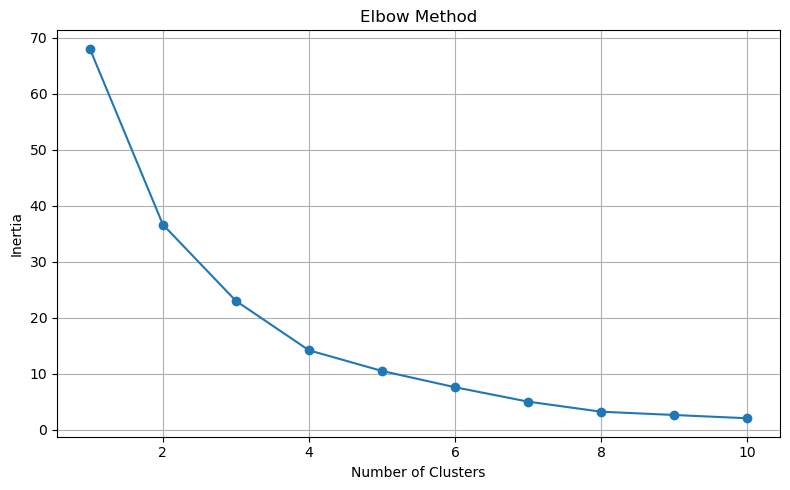

In [120]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/elbow_method.png")

plt.show()

In [121]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_features["Cluster"] = kmeans.fit_predict(
    scaled_features
)

C:\Users\Farhana Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [122]:
product_features

,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,337.723800,0.395482,2
Appliances,104618.4030,227.926804,378.006735,0.545645,2
Art,26705.4100,34.019631,60.301752,0.498255,2
Binders,200028.7850,134.067550,568.099970,0.463863,2
Bookcases,113813.1987,503.598224,641.419280,0.142674,1
Chairs,322822.7310,531.833165,551.180296,0.137445,3
Copiers,146248.0940,2215.880212,3216.185499,0.357947,0
Envelopes,16128.0460,65.032444,85.170691,-0.241905,1
Fasteners,3001.9600,14.027850,12.466864,-0.096378,1


In [123]:
from sklearn.decomposition import PCA

In [124]:
pca = PCA(n_components=2)

reduced_data = pca.fit_transform(
    scaled_features
)

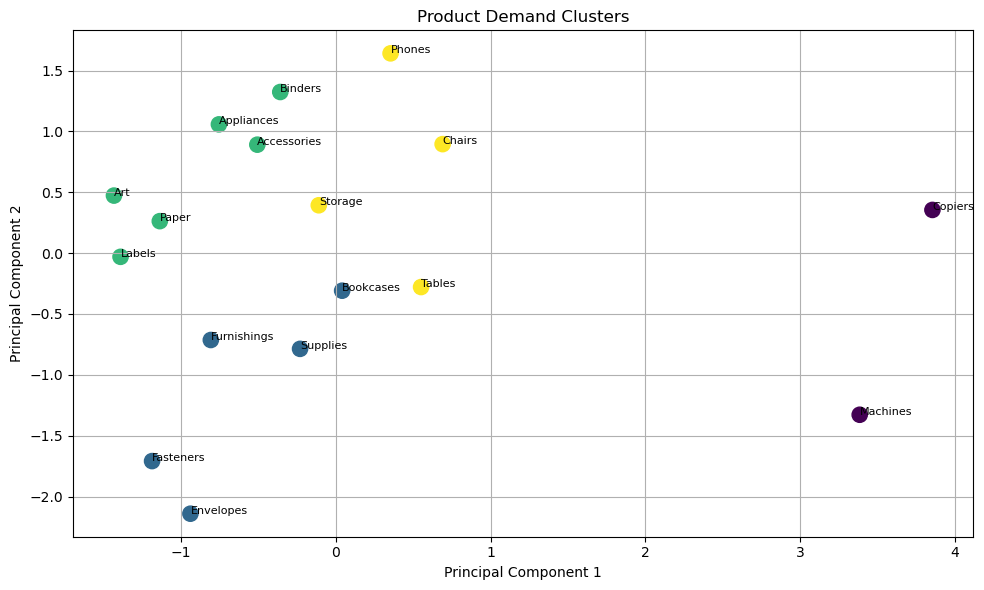

In [125]:
plt.figure(figsize=(10,6))

plt.scatter(
    reduced_data[:,0],
    reduced_data[:,1],
    c=product_features["Cluster"],
    s=120
)

for i, label in enumerate(product_features.index):
    plt.text(
        reduced_data[i,0],
        reduced_data[i,1],
        label,
        fontsize=8
    )

plt.title("Product Demand Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/product_clusters.png")

plt.show()

In [126]:
cluster_names = {
    0: "High Volume Stable Demand",
    1: "Growing Demand",
    2: "Low Volume High Volatility",
    3: "Moderate Demand"
}

product_features["Cluster_Name"] = (
    product_features["Cluster"]
    .map(cluster_names)
)

product_features

,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate,Cluster,Cluster_Name
Sub-Category,,,,,,
Accessories,164186.7000,217.178175,337.723800,0.395482,2,Low Volume High Volatility
Appliances,104618.4030,227.926804,378.006735,0.545645,2,Low Volume High Volatility
Art,26705.4100,34.019631,60.301752,0.498255,2,Low Volume High Volatility
Binders,200028.7850,134.067550,568.099970,0.463863,2,Low Volume High Volatility
Bookcases,113813.1987,503.598224,641.419280,0.142674,1,Growing Demand
Chairs,322822.7310,531.833165,551.180296,0.137445,3,Moderate Demand
Copiers,146248.0940,2215.880212,3216.185499,0.357947,0,High Volume Stable Demand
Envelopes,16128.0460,65.032444,85.170691,-0.241905,1,Growing Demand
Fasteners,3001.9600,14.027850,12.466864,-0.096378,1,Growing Demand


## Stocking Strategy Recommendations

### High Volume Stable Demand
Maintain consistent inventory with regular replenishment.

### Growing Demand
Increase inventory gradually and monitor future demand closely.

### Low Volume High Volatility
Keep limited stock and reorder based on demand trends.

### Moderate Demand
Maintain balanced inventory levels while monitoring seasonal fluctuations.